In [1]:
import os
from typing import TypedDict, Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

C:\Users\new\AppData\Local\Temp\ipykernel_45104\3355621483.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
e:\Summer-2026-projects\Langgraph-practice\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
##Load an pdf
loader = PyPDFLoader("About_khan.pdf")

documents = loader.load()

print(f"Loaded PDF pages: {len(documents)}")


Loaded PDF pages: 107


In [4]:
# ============================================================
# 3. CHUNKING
# ============================================================

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(documents)

print(f"Total chunks: {len(chunks)}")


Total chunks: 359


In [5]:
# ============================================================
# 4. EMBEDDINGS
# ============================================================

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1467.40it/s]


In [6]:
# ============================================================
# 5. VECTOR DATABASE
# ============================================================

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db"
)


In [7]:
# ============================================================
# 6. RETRIEVER
# ============================================================

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 5
    }
)

In [8]:
# ============================================================
# 7. GROQ LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)



In [9]:
# ============================================================
# 8. For Structured output
# ============================================================

class DocumentEvaluation(BaseModel):

    score: float = Field(
        description=(
            "Relevance score from 0 to 1. "
            "0 means completely irrelevant, "
            "1 means highly relevant."
        )
    )

    reason: str = Field(
        description="Short explanation of why the document is or is not relevant."
    )


evaluator_llm = llm.with_structured_output(
    DocumentEvaluation
)

In [10]:
# ============================================================
# 9. WEB SEARCH
# ============================================================

web_search = TavilySearch(
    max_results=5
)



In [11]:
# ============================================================
# 10. GRAPH STATE
# ============================================================

class CRAGState(TypedDict, total=False):

    question: str

    retrieved_docs: list

    evaluated_docs: list

    relevant_docs: list

    decision: str

    rewritten_query: str

    web_results: str

    local_context: str

    final_context: str

    answer: str


In [12]:
# ============================================================
# 11. RETRIEVE NODE
# ============================================================

def retrieve(state: CRAGState):

    question = state["question"]

    docs = retriever.invoke(question)

    print("\n================ RETRIEVE ================")
    print(f"Retrieved documents: {len(docs)}")

    return {
        "retrieved_docs": docs
    }


In [13]:
# ============================================================
# 12. EVALUATE EACH DOCUMENT
# ============================================================

def evaluate_documents(state: CRAGState):

    question = state["question"]
    docs = state["retrieved_docs"]

    evaluated_docs = []

    print("\n================ EVALUATION ================")

    for i, doc in enumerate(docs):

        prompt = f"""
You are a retrieval evaluator for a Corrective RAG system.

Evaluate whether the document is relevant to answering the user's question.

USER QUESTION:
{question}

DOCUMENT:
{doc.page_content}

Give a relevance score between 0 and 1.

0.0 = completely irrelevant
0.5 = partially relevant
1.0 = highly relevant

Only judge relevance to the question.
"""

        result = evaluator_llm.invoke(prompt)

        score = max(0.0, min(1.0, result.score))

        evaluated_docs.append({
            "document": doc,
            "score": score,
            "reason": result.reason
        })

        print(f"\nDocument {i + 1}")
        print(f"Score: {score:.2f}")
        print(f"Reason: {result.reason}")

    return {
        "evaluated_docs": evaluated_docs
    }



In [14]:
# ============================================================
# 13. DECIDE CORRECT / AMBIGUOUS / INCORRECT
# ============================================================

def classify_retrieval(state: CRAGState):

    evaluated_docs = state["evaluated_docs"]

    scores = [
        item["score"]
        for item in evaluated_docs
    ]

    max_score = max(scores) if scores else 0.0

    print("\n================ CLASSIFICATION ================")
    print(f"Maximum relevance score: {max_score:.2f}")

    # --------------------------------------------------------
    # Practical thresholds for our LLM-based implementation
    # --------------------------------------------------------

    CORRECT_THRESHOLD = 0.70
    AMBIGUOUS_THRESHOLD = 0.30

    if max_score >= CORRECT_THRESHOLD:

        decision = "correct"

    elif max_score >= AMBIGUOUS_THRESHOLD:

        decision = "ambiguous"

    else:

        decision = "incorrect"

    print(f"Decision: {decision.upper()}")

    return {
        "decision": decision
    }

In [15]:
# ============================================================
# 14. ROUTER
# ============================================================

def route_after_evaluation(
    state: CRAGState
) -> Literal["correct", "ambiguous", "incorrect"]:

    return state["decision"]


In [16]:
# ============================================================
# 15. CREATE LOCAL KNOWLEDGE STRIPS
# ============================================================

def create_local_strips(state: CRAGState):

    evaluated_docs = state["evaluated_docs"]

    relevant_docs = []

    for item in evaluated_docs:

        if item["score"] >= 0.30:

            relevant_docs.append(item["document"])

    print("\n================ LOCAL STRIPS ================")
    print(f"Relevant local documents: {len(relevant_docs)}")

    return {
        "relevant_docs": relevant_docs
    }



In [17]:
# ============================================================
# 16. REFINE LOCAL KNOWLEDGE
# ============================================================

def refine_local_knowledge(state: CRAGState):

    question = state["question"]
    docs = state.get("relevant_docs", [])

    if not docs:

        return {
            "local_context": ""
        }

    combined = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    prompt = f"""
You are refining retrieved knowledge for a RAG system.

USER QUESTION:
{question}

RETRIEVED KNOWLEDGE:
{combined}

Remove information that is irrelevant to the question.

Keep only the facts that can help answer the user's question.

Do not invent new information.

Return the refined knowledge only.
"""

    result = llm.invoke(prompt)

    print("\n================ LOCAL REFINEMENT ================")

    return {
        "local_context": result.content
    }



In [18]:
# ============================================================
# 17. REWRITE QUERY
# ============================================================

def rewrite_query(state: CRAGState):

    question = state["question"]

    prompt = f"""
Rewrite the following user question into a better search query.

Original question:
{question}

The query will be sent to a web search engine.

Make it:
- clear
- specific
- searchable
- concise

Return only the rewritten search query.
"""

    result = llm.invoke(prompt)

    rewritten_query = result.content.strip()

    print("\n================ QUERY REWRITE ================")
    print(f"Original: {question}")
    print(f"Rewritten: {rewritten_query}")

    return {
        "rewritten_query": rewritten_query
    }



In [35]:
def perform_web_search(state: CRAGState):

    query = state.get("rewritten_query")

    if not query:
        query = state["question"]

    print("\n================ WEB SEARCH ================")
    print(f"Searching: {query}")

    result = web_search.invoke({
        "query": query
    })

    return {
        "web_results": str(result)
    }

In [36]:
# ============================================================
# 19. ROUTE AFTER LOCAL REFINEMENT
# ============================================================

def route_after_local_refinement(
    state: CRAGState
) -> Literal["web_search", "merge"]:

    if state["decision"] == "ambiguous":

        return "web_search"

    return "merge"



In [37]:
def merge_knowledge(state: CRAGState):

    decision = state["decision"]

    local_context = state.get(
        "local_context",
        ""
    )

    web_results = state.get(
        "web_results",
        ""
    )

    print("\n================ MERGE ================")

    # --------------------------------------------------------
    # CORRECT
    # --------------------------------------------------------

    if decision == "correct":

        final_context = local_context

    # --------------------------------------------------------
    # AMBIGUOUS
    # --------------------------------------------------------

    elif decision == "ambiguous":

        final_context = f"""
LOCAL KNOWLEDGE:

{local_context}

EXTERNAL WEB KNOWLEDGE:

{web_results}
"""

    # --------------------------------------------------------
    # INCORRECT
    # --------------------------------------------------------

    else:

        final_context = web_results

    return {
        "final_context": final_context
    }

In [38]:


# ============================================================
# 21. GENERATE FINAL ANSWER
# ============================================================

def generate_answer(state: CRAGState):

    question = state["question"]

    context = state.get(
        "final_context",
        ""
    )

    prompt = f"""
You are a helpful AI assistant.

Answer the user's question using the provided knowledge.

USER QUESTION:
{question}

KNOWLEDGE:
{context}

Rules:

1. Use the provided knowledge.
2. Do not invent facts.
3. If the knowledge does not contain enough information, say so.
4. Give a clear and useful answer.
"""

    result = llm.invoke(prompt)

    answer = result.content

    print("\n================ FINAL ANSWER ================")
    print(answer)

    return {
        "answer": answer
    }


In [44]:
graph = StateGraph(CRAGState)


# ============================================================
# NODES
# ============================================================

graph.add_node("retrieve", retrieve)
graph.add_node("evaluate", evaluate_documents)
graph.add_node("classify", classify_retrieval)

graph.add_node("create_strips", create_local_strips)
graph.add_node("refine_local", refine_local_knowledge)

graph.add_node("rewrite_query", rewrite_query)
graph.add_node("web_search", perform_web_search)

graph.add_node("merge", merge_knowledge)
graph.add_node("generate", generate_answer)


# ============================================================
# START → RETRIEVE
# ============================================================

graph.add_edge(
    START,
    "retrieve"
)


# ============================================================
# RETRIEVE → EVALUATE
# ============================================================

graph.add_edge(
    "retrieve",
    "evaluate"
)


# ============================================================
# EVALUATE → CLASSIFY
# ============================================================

graph.add_edge(
    "evaluate",
    "classify"
)


# ============================================================
# CLASSIFY → CORRECT / AMBIGUOUS / INCORRECT
# ============================================================

graph.add_conditional_edges(
    "classify",
    route_after_evaluation,
    {
        # Correct retrieval
        "correct": "create_strips",

        # Ambiguous retrieval
        "ambiguous": "create_strips",

        # Incorrect retrieval
        "incorrect": "rewrite_query"
    }
)


# ============================================================
# CORRECT / AMBIGUOUS → CREATE STRIPS
# ============================================================

graph.add_edge(
    "create_strips",
    "refine_local"
)


# ============================================================
# REFINE LOCAL
# → MERGE      (Correct)
# → WEB SEARCH (Ambiguous)
# ============================================================

graph.add_conditional_edges(
    "refine_local",
    route_after_local_refinement,
    {
        "web_search": "web_search",
        "merge": "merge"
    }
)


# ============================================================
# INCORRECT → REWRITE QUERY → WEB SEARCH
# ============================================================

graph.add_edge(
    "rewrite_query",
    "web_search"
)


# ============================================================
# WEB SEARCH → MERGE
# ============================================================

graph.add_edge(
    "web_search",
    "merge"
)


# ============================================================
# MERGE → GENERATE
# ============================================================

graph.add_edge(
    "merge",
    "generate"
)


# ============================================================
# GENERATE → END
# ============================================================

graph.add_edge(
    "generate",
    END
)


# ============================================================
# COMPILE GRAPH
# ============================================================

app = graph.compile()

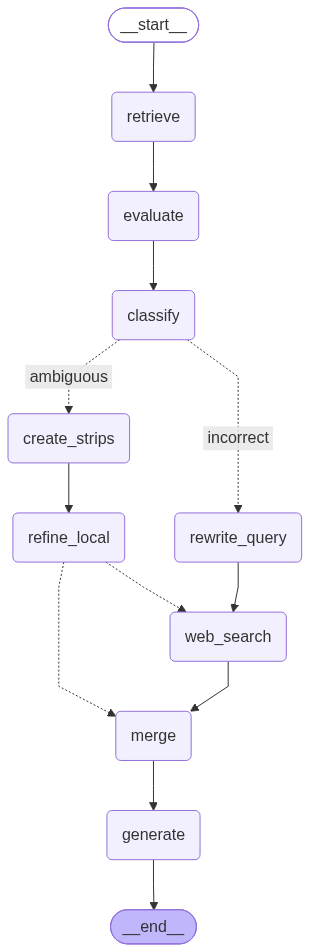

In [45]:
app

In [41]:
# ============================================================
# 25. CHAT LOOP
# ============================================================

if __name__ == "__main__":

    print("\n==========================================")
    print("       CRAG CHATBOT")
    print("==========================================")
    print("Type 'exit' to stop.")

    while True:

        question = input("\nYou: ").strip()

        if question.lower() in [
            "exit",
            "quit"
        ]:

            print("Goodbye!")
            break

        if not question:

            continue

        result = app.invoke({
            "question": question
        })

        print("\n------------------------------------------")
        print("FINAL RESPONSE:")
        print(result["answer"])
        print("------------------------------------------")


       CRAG CHATBOT
Type 'exit' to stop.

================ RETRIEVE ================
Retrieved documents: 5

================ EVALUATION ================

Document 1
Score: 0.70
Reason: The document describes Bahawal Khan's goals (using AI/ML in his professional direction), lists his technical skills, and states he has completed the sixth semester. However, it does not provide his CGPA, so the answer would be incomplete.

Document 2
Score: 0.05
Reason: The document discusses a technical learning plan and ML/DL topics, with no information about Khan's personal goal, skills, semester, or CGPA, which are the specifics asked.

Document 3
Score: 0.05
Reason: The document discusses a technical learning plan and AI concepts related to Bahawal Khan, but it does not provide information about Khan's personal goal, skills, semester, or CGPA. Therefore it does not answer the user's query.

Document 4
Score: 0.10
Reason: The document discusses a technical learning plan and ML/DL topics, with no in